In [2]:
#importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
%matplotlib inline

In [3]:
#loading the mnist dataset
mnist=fetch_openml('mnist_784',version=1)
X=mnist.data
y=mnist.target
X=X/255.0

In [4]:
#splitting the dataset
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=5)

In [5]:
#fitting the model
model=LogisticRegression(max_iter=300)
model.fit(X_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",300
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [6]:
model.n_iter_

array([259], dtype=int32)

By trial and error method the max_iter can be decided and as the X value is normalized the model converges faster, with less iteration

In [7]:
# Testing based on the training data
y_train_pred=model.predict(X_train)
train_acc=accuracy_score(y_train,y_train_pred)
print(f'Training accuracy: {train_acc:.2f}%')

Training accuracy: 0.94%


In [8]:
#Testing based on the test data
y_test_pred=model.predict(X_test)
test_acc=accuracy_score(y_test,y_test_pred)
print(f'Test accuracy: {test_acc:.2f}%')

Test accuracy: 0.93%


Getting the indices of the correct and wrong predictions that are limited to 5

In [9]:
#Display the correct and wrong predictions indices
crt_pred_ind=[]
wrg_pred_ind=[]
#As the y_test is of pandas format while the prediction(y_test_pred) is in numpy, converting y_test to numpy format
y_test_arr=y_test.to_numpy() 
for i in range(len(y_test_pred)):
    if((len(crt_pred_ind)<5) and (y_test_pred[i] == y_test_arr[i])):
        crt_pred_ind.append(i)
    elif((len(wrg_pred_ind)<5) and (y_test_pred[i] != y_test_arr[i])):
        wrg_pred_ind.append(i)
    elif((len(crt_pred_ind)==5) and (len(wrg_pred_ind)==5)):
        break
print(f'Crt ind: {crt_pred_ind}')
print(f'Wrg ind: {wrg_pred_ind}')

Crt ind: [0, 1, 2, 3, 4]
Wrg ind: [56, 64, 83, 90, 95]


Five Correct predictions are visualized below

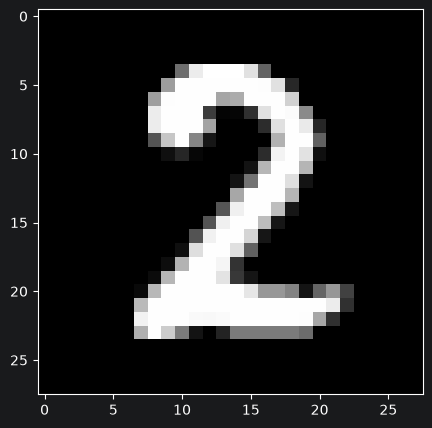

Actual :2
Predicted:2
----------*--------------------*--------------------*--------------------*--------------------*----------


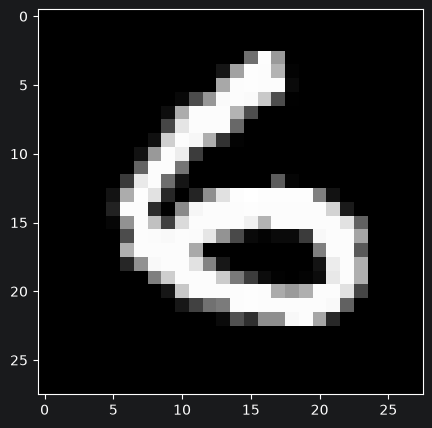

Actual :6
Predicted:6
----------*--------------------*--------------------*--------------------*--------------------*----------


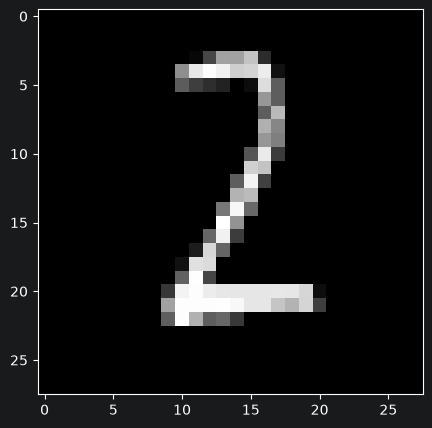

Actual :2
Predicted:2
----------*--------------------*--------------------*--------------------*--------------------*----------


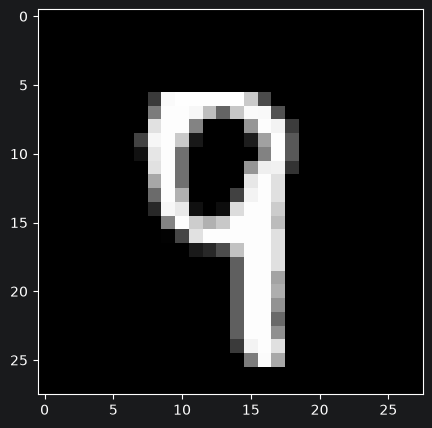

Actual :9
Predicted:9
----------*--------------------*--------------------*--------------------*--------------------*----------


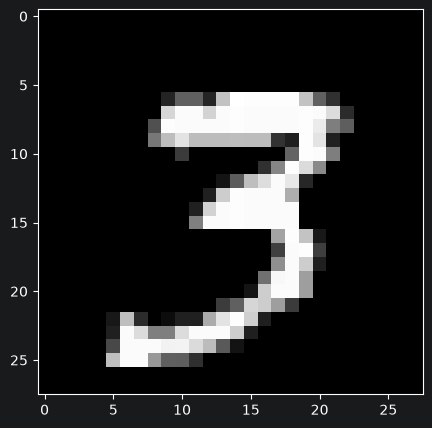

Actual :3
Predicted:3
----------*--------------------*--------------------*--------------------*--------------------*----------


In [10]:
for i in crt_pred_ind:
    plt.figure(figsize=(5,5))
    X=(X_test.iloc[i].values)*255.0
    plt.imshow(X.reshape(28,28),cmap='gray')
    plt.show()
    print(f'Actual :{y_test_arr[i]}')
    print(f'Predicted:{y_test_pred[i]}')
    print('----------*----------'*5)

Five Wrong predictions are visualized below

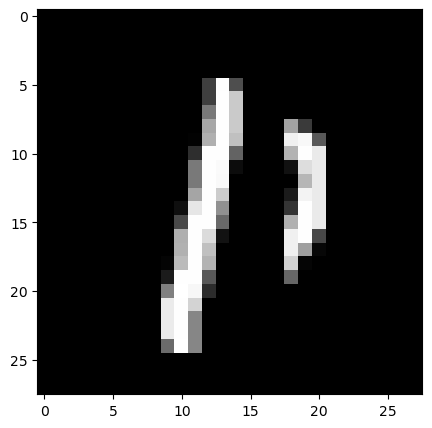

Actual :1
Predicted:0
----------*--------------------*--------------------*--------------------*--------------------*----------


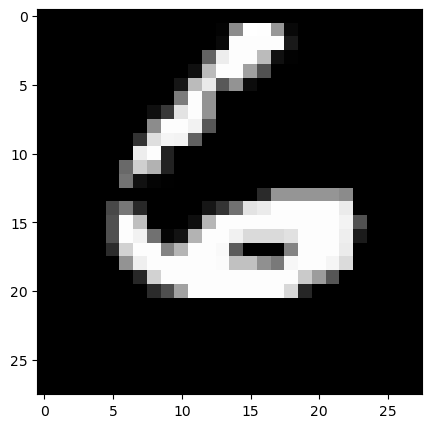

Actual :6
Predicted:2
----------*--------------------*--------------------*--------------------*--------------------*----------


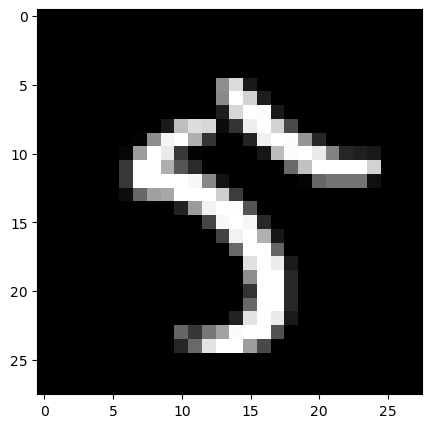

Actual :5
Predicted:8
----------*--------------------*--------------------*--------------------*--------------------*----------


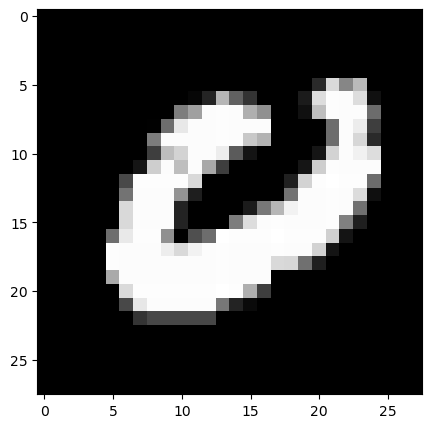

Actual :0
Predicted:6
----------*--------------------*--------------------*--------------------*--------------------*----------


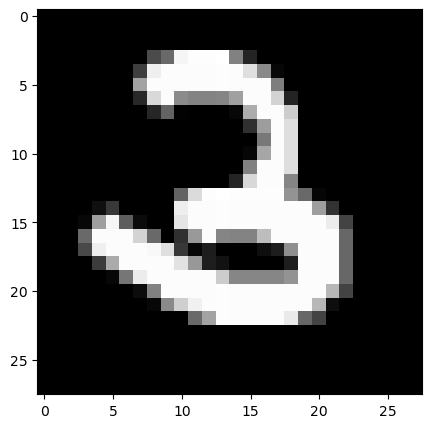

Actual :3
Predicted:2
----------*--------------------*--------------------*--------------------*--------------------*----------


In [49]:
for i in wrg_pred_ind:
    plt.figure(figsize=(5,5))
    X=(X_test.iloc[i].values)*255.0
    plt.imshow(X.reshape(28,28),cmap='gray')
    plt.show()
    print(f'Actual :{y_test_arr[i]}')
    print(f'Predicted:{y_test_pred[i]}')
    print('----------*----------'*5)